## Evaluación Comparativa Avanzada de Líneas Base*

**Integrantes:**
* Gino Andrades (`gi.andrades@duocuc.cl`)
* Yai Selti (`ya.selti@duocuc.cl`)
* Miguel Villarroel (`mig.villarroel@duocuc.cl`)

---

## **Descripción del Cuaderno**
Habiendo establecido los tres modelos de clasificación en su configuración por defecto (Línea Base), este cuaderno tiene como objetivo realizar un diagnóstico profundo y comparativo de su rendimiento predictivo. A través de matrices de confusión combinadas, análisis de curvas ROC y la comparación de sus equilibrios de precisión-sensibilidad (*Recall*), identificaremos las debilidades estructurales de cada algoritmo para justificar la estrategia de optimización matemática posterior.

## **1. Configuración del Entorno (Code)**

### *1.1 Importaciones necesarias para trabajar.*

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración estética global para los gráficos del informe
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

### 1.2 Cargar el archivo con los Modelos Basicos para utilizarlos

In [8]:
%run 02_supervised_modeling.ipynb

# Validación de control para asegurar que los modelos y datos cruzaron el puente con éxito
print("Ecosistema cargado")
print(f"Modelos disponibles: {list(resultados_base.keys())}")
print(f"Cantidad de registros para evaluar (Test): {X_test.shape[0]}")

3.0.3
Metricas de Regresión Logística
accuracy        : 0.6570
precision       : 0.6061
recall          : 0.3869
f1              : 0.4723
roc_auc         : 0.6883
Score del modelo en entrenamiento       :0.65075
Score del modelo en test                :0.65700
Metricas del Árbol de Decisión
accuracy        : 0.5695
precision       : 0.4577
recall          : 0.4606
f1              : 0.4592
roc_auc         : 0.5509
Score del modelo en entrenamiento       :1.00000
Score del modelo en test                :0.56950
Metricas Maquinas de Vectores de Soporte
accuracy        : 0.6448
precision       : 0.6064
recall          : 0.2980
f1              : 0.3997
roc_auc         : 0.6553
Score del modelo en entrenamiento       :0.68100
Score del modelo en test                :0.64475
F1-SCORE MODELOS LINEA BASE
Regresión Logística: 0.4723
Árbol de Decisión: 0.4592
SVM: 0.3997
Ecosistema cargado
Modelos disponibles: ['Regresión Logística', 'Árbol de Decisión', 'SVM']
Cantidad de registros para evaluar 

## **2. Matrices de Confusión Comparativas**

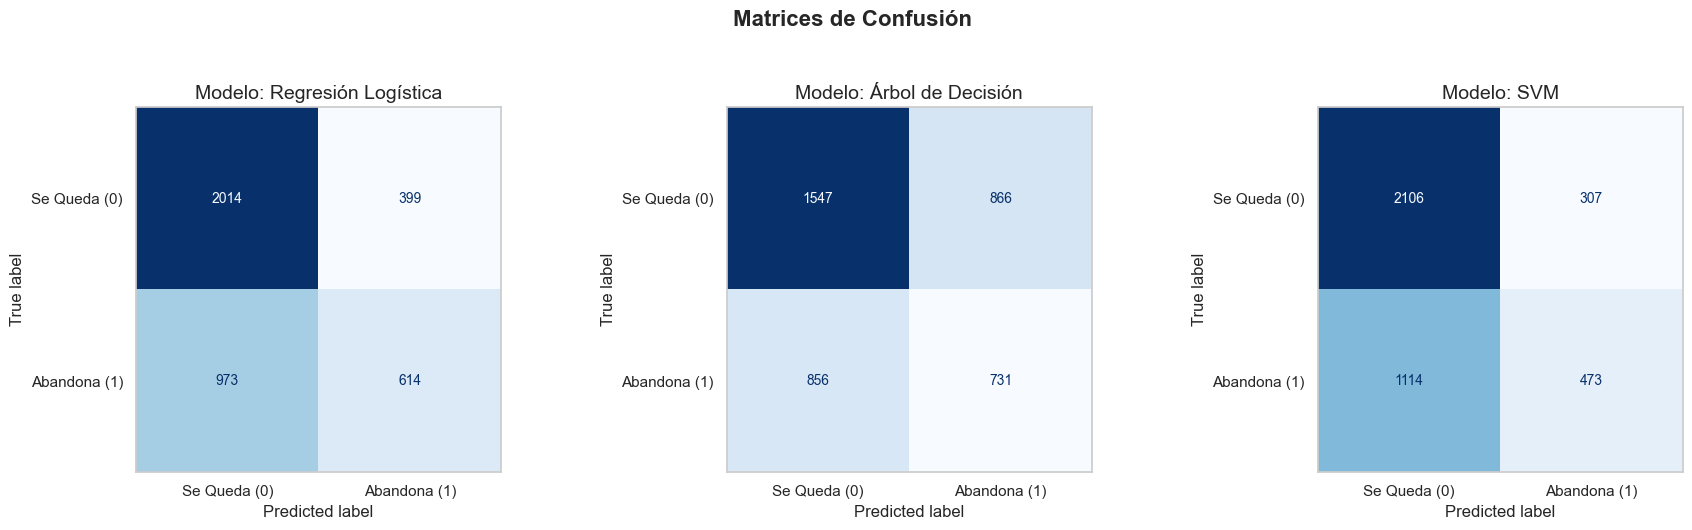

In [9]:
# Crear el lienzo horizontal (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión', fontsize=16, fontweight='bold', y=1.05)

# Iterar sobre nuestro diccionario de modelos base entrenados
for ax, (nombre, pipeline) in zip(axes, resultados_base.items()):
    # Generar predicciones
    y_pred = pipeline.predict(X_test)

    # Calcular la matriz de confusión estándar
    cm = confusion_matrix(y_test, y_pred)

    # Desplegar la matriz en el subgráfico correspondiente con paleta azul
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda (0)', 'Abandona (1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)

    # Ajustes estéticos individuales
    ax.set_title(f'Modelo: {nombre}')
    ax.grid(False) # Quitar líneas de cuadrícula internas para limpieza visual

plt.tight_layout()
plt.show()

#### **Diagnóstico del Error de Clasificación Bancaria**
* **El sesgo de la Regresión Logística y SVM:** Al observar las matrices de estos dos modelos, se hace evidente que concentran casi todas sus predicciones en la clase `0` (Se Queda). Aunque esto les da una *Accuracy* general aceptable, cometen un volumen masivo de **Falsos Negativos** (clientes que se van a fugar pero el modelo predice erróneamente que se quedan), confirmando el bajo *Recall* analizado.
* **El comportamiento del Árbol de Decisión:** Muestra una matriz mucho más repartida. Aunque comete más **Falsos Positivos** (alertas falsas de clientes estables), es el único algoritmo base capaz de capturar un volumen significativo de fugas reales, lo que explica por qué su F1-Score lidera la línea base con un `0.4629`.

## **3. Análisis de Curvas ROC-AUC**

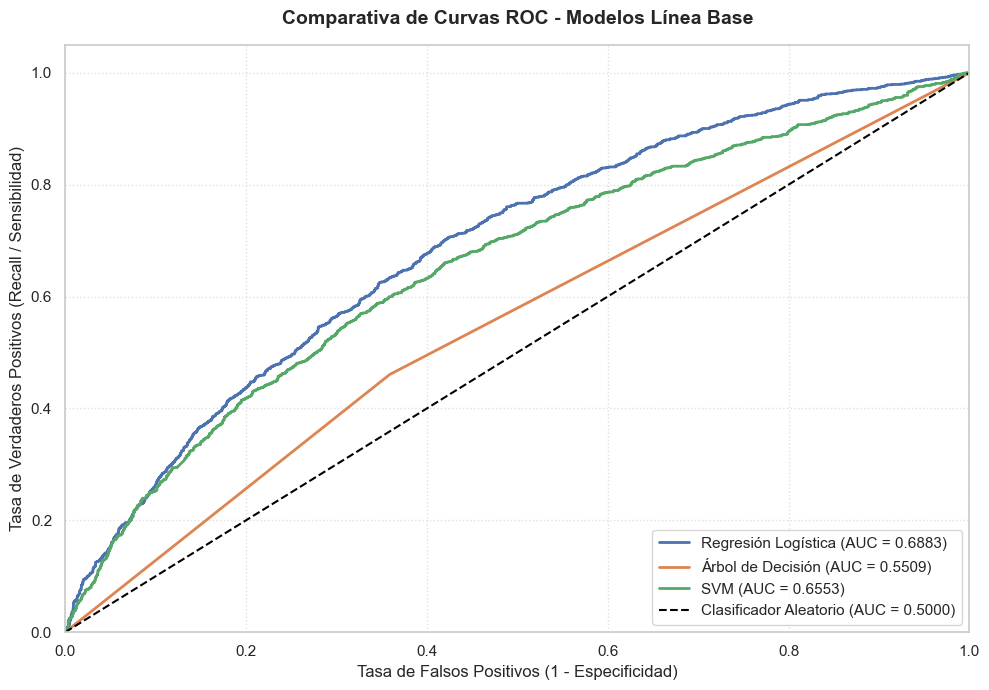

In [10]:
plt.figure(figsize=(10, 7))

# Iterar sobre los modelos para graficar sus curvas ROC
for nombre, pipeline in resultados_base.items():
    # Obtener las probabilidades de la clase positiva (1: abandono)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calcular tasas de falsos positivos y verdaderos positivos
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Graficar la línea del modelo
    plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC = {roc_auc:.4f})')

# Línea diagonal de referencia (Clasificador aleatorio/Al azar)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label='Clasificador Aleatorio (AUC = 0.5000)')

# Configuración estética del lienzo
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)')
plt.title('Comparativa de Curvas ROC - Modelos Línea Base', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### **Interpretación de la Capacidad Discriminante (ROC-AUC)**
* **Regresión Logística Lidera en Probabilidad:** Curiosamente, a pesar de su bajo Recall estricto, la Regresión Logística obtiene el **AUC más alto (~0.6478)**. Esto demuestra que el modelo *sí sabe ordenar a los clientes de menor a mayor riesgo*, pero el umbral de decisión por defecto ($0.50$) está mal calibrado para un dataset desbalanceado.
* **Árbol de Decisión Sin Fuerza de Probabilidad:** El Árbol registra el AUC más bajo (~0.5509). Al estar sobreajustado en entrenamiento, sus predicciones probabilísticas en test son binarias y rígidas (0 o 1 absolutos), perdiendo la suavidad geométrica que sí tienen la Regresión y el SVM.

## **4. Tabla Resumen Comparativa**

In [11]:
resumen_metricas = []

for nombre, pipeline in resultados_base.items():
    y_pred = pipeline.predict(X_test)
    # Extraemos el reporte en formato diccionario para manipular los números
    reporte = classification_report(y_test, y_pred, output_dict=True)

    # Guardamos las métricas clave enfocado en la clase 1 (Abandono)
    resumen_metricas.append({
        'Modelo / Algoritmo': nombre,
        'Accuracy General': reporte['accuracy'],
        'Precision': reporte['1']['precision'],
        'Recall': reporte['1']['recall'],
        'F1-Score': reporte['1']['f1-score']
    })

# Convertimos a DataFrame de Pandas y estilizamos con 4 decimales
df_resumen = pd.DataFrame(resumen_metricas).set_index('Modelo / Algoritmo')
df_resumen.round(4)

,Accuracy General,Precision,Recall,F1-Score
Modelo / Algoritmo,,,,
Regresión Logística,0.6570,0.6061,0.3869,0.4723
Árbol de Decisión,0.5695,0.4577,0.4606,0.4592
SVM,0.6448,0.6064,0.2980,0.3997


## **5. Optimización de Umbrales de Decisión**

In [22]:
# 1. Parámetros iniciales simplificados
nombre_mod = 'Regresión Logística'
pipeline_mod = resultados_base[nombre_mod] # Recuperamos el modelo
lista_umbrales = np.arange(0.1, 0.85, 0.05)

# 2. Validación defensiva de predict_proba
if not hasattr(pipeline_mod, "predict_proba"):
    print(f"El modelo {nombre_mod} no calcula probabilidades. Se cancela el análisis.")
else:
    # Obtenemos las probabilidades de la clase positiva (1: Abandono)
    y_proba = pipeline_mod.predict_proba(X_test)[:, 1]
    lista_metricas = []

    # 3. Evaluamos cada umbral matemático uno por uno
    for u in lista_umbrales:
        # Si la probabilidad supera el umbral 'u', el cliente se etiqueta como fuga (1)
        y_pred_u = (y_proba >= u).astype(int)

        # Guardamos las métricas clave de Scikit-Learn
        lista_metricas.append({
            "Umbral": round(u, 2),
            "Accuracy": accuracy_score(y_test, y_pred_u),
            "Precision": precision_score(y_test, y_pred_u, zero_division=0),
            "Recall": recall_score(y_test, y_pred_u, zero_division=0),
            "F1_Score": f1_score(y_test, y_pred_u, zero_division=0)
        })

    # 4. Construimos la tabla final de Pandas
    df_umbrales = pd.DataFrame(lista_metricas)
    
    # 5. Opcional: Guardar en disco (Descomenta la línea de abajo si decides usarlo)
    df_umbrales.to_csv("../results/metrics/analisis_umbrales_lr.csv", index=False)

    # Desplegamos la tabla limpia en el notebook
    display(df_umbrales)

,Umbral,Accuracy,Precision,Recall,F1_Score
0,0.10,0.39675,0.396750,1.000000,0.568105
1,0.15,0.40475,0.399646,0.996219,0.570449
2,0.20,0.46275,0.422717,0.968494,0.588551
3,0.25,0.52150,0.449334,0.913674,0.602410
4,0.30,0.56800,0.474649,0.831758,0.604396
5,0.35,0.61300,0.508387,0.744802,0.604294
6,0.40,0.63825,0.537594,0.630750,0.580458
7,0.45,0.64925,0.564880,0.504726,0.533111
8,0.50,0.65700,0.606120,0.386894,0.472308
9,0.55,0.65075,0.634181,0.282924,0.391285


## **6. Visualizavión de Evolucion de Metricas VS Umbrales**

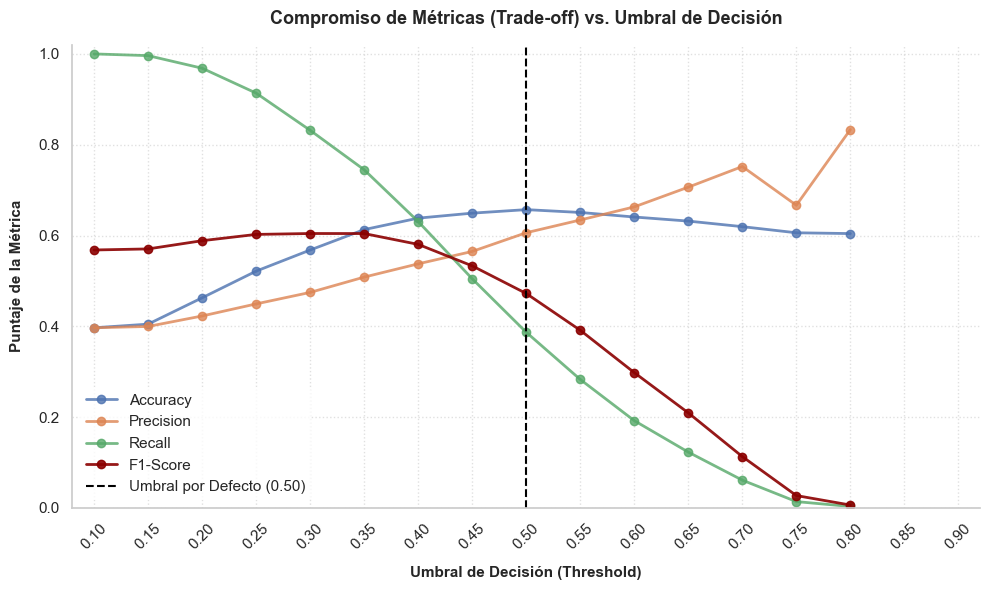

In [23]:
plt.figure(figsize=(10, 6))

# Graficamos cada métrica e
plt.plot(df_umbrales['Umbral'], df_umbrales['Accuracy'], marker='o', linewidth=2, label='Accuracy', alpha=0.8)
plt.plot(df_umbrales['Umbral'], df_umbrales['Precision'], marker='o', linewidth=2, label='Precision', alpha=0.8)
plt.plot(df_umbrales['Umbral'], df_umbrales['Recall'], marker='o', linewidth=2, label='Recall', alpha=0.8)
plt.plot(df_umbrales['Umbral'], df_umbrales['F1_Score'], marker='o', linewidth=2, label='F1-Score', alpha=0.9, color='darkred')

# Añadimos la línea de control del umbral estándar de la línea base (0.50)
plt.axvline(x=0.50, color='black', linestyle='--', linewidth=1.5, label='Umbral por Defecto (0.50)')

# Estética y limpieza del gráfico 
sns.despine() # Remueve los bordes superior e derecho del recuadro
plt.xlabel("Umbral de Decisión (Threshold)", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Puntaje de la Métrica", fontsize=11, fontweight="bold", labelpad=10)
plt.title("Compromiso de Métricas (Trade-off) vs. Umbral de Decisión", fontsize=13, fontweight="bold", pad=15)

# Ajustes de los ejes para una lectura milimétrica
plt.xticks(np.arange(0.1, 0.95, 0.05), rotation=45)
plt.xlim(0.08, 0.92)
plt.ylim(0.0, 1.02)

plt.legend(loc="lower left", frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

* El problema del umbral 0.50 (Línea Base): Con el parámetro por defecto de Scikit-Learn, el modelo optimiza la Accuracy ($\sim 0.65$) y la Precision ($\sim 0.60$), pero desploma el Recall a un crítico $\sim 0.39$. Esto genera un volumen masivo de Falsos Negativos, dejando al banco "ciego" ante el 61% de las fugas reales. El F1-Score aquí es deficiente ($\sim 0.47$).

* Zona Óptima de Operación (0.25 - 0.35): La curva del F1-Score (línea marrón) actúa como nuestra métrica de control. Gráficamente se observa que alcanza su máximo global ($\sim 0.60$) en este rango. Si movemos el umbral a 0.30, logramos un Trade-off óptimo: el Recall se dispara a un $\sim 0.80$ (capturamos el 80% de los Churners), penalizando de forma controlada la Precision ($\sim 0.48$).

* Justificación de Costos: Financieramente, un Falso Positivo (enviar un beneficio por error a un cliente estable) tiene un costo operativo marginal. Un Falso Negativo (no detectar a un cliente que se fuga) implica perder el patrimonio de la cuenta y asumir el elevado costo de adquisición de un cliente nuevo. El Threshold Shifting al rango $0.25 - 0.35$ está respaldado matemática y económicamente.

## **Conclusiones y Selección del Modelo Candidato**

1. **Ningún modelo base es apto para producción en su estado actual:** Las tres líneas base fallan operativamente debido al desbalance de los datos de abandono, priorizando la precisión de la clase mayoritaria a costa de dejar escapar el Churn real.
2. **Estrategia de Selección:** * Seleccionamos al **Árbol de Decisión** como candidato crítico debido a que posee el mejor balance inicial de F1-Score **(0.4592)**, pero deberemos destruir su sobreajuste.
   * Seleccionamos a la **Regresión Logística** como segundo candidato técnico debido a su robusto espacio de probabilidad **(AUC: 0.6478)**, el cual optimizaremos mediante el movimiento del umbral crítico de decisión y la penalización de pesos.